In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Churn_Modelling.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Mounted at /content/drive
Dataset loaded successfully!
Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0

Column Names: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing Values: 0

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage: 20.37 %


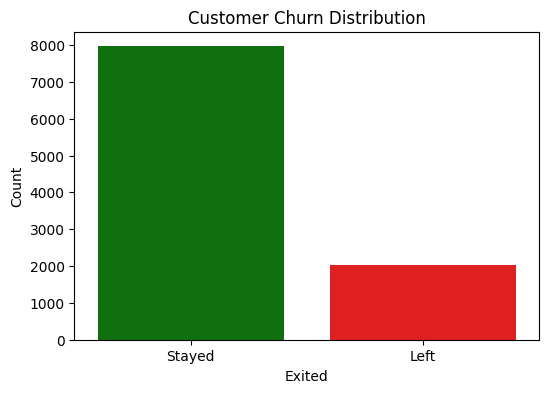

In [3]:
# Explore the data
print("Column Names:", df.columns.tolist())
print("\nMissing Values:", df.isnull().sum().sum())
print("\nChurn Distribution:")
print(df['Exited'].value_counts())
print("\nChurn Percentage:", round(df['Exited'].value_counts()[1]/len(df)*100, 2), "%")

# Visualize churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette=['green','red'])
plt.title('Customer Churn Distribution')
plt.xticks([0,1], ['Stayed', 'Left'])
plt.ylabel('Count')
plt.show()




In [4]:
# Prepare the data
# Drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical columns
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

# Features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Data preparation complete!")

Training set size: (8000, 10)
Testing set size: (2000, 10)
Data preparation complete!


Model Comparison:
Logistic Regression: 80.5%
Random Forest:       86.4%
XGBoost:             84.7%


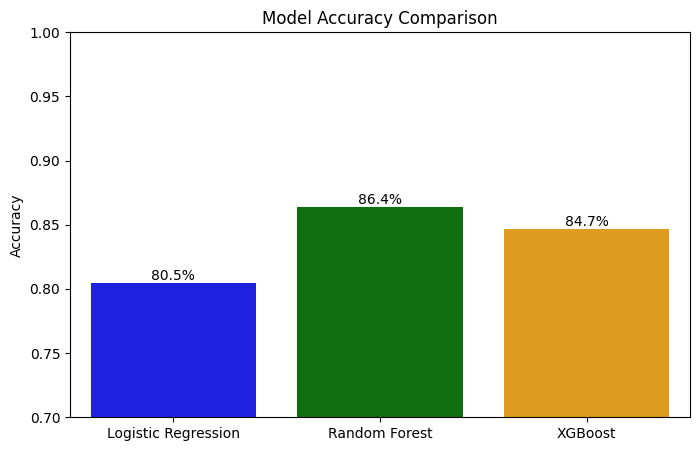

In [7]:
# Train and Compare 3 Models

# Model 1 - Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Model 3 - XGBoost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

# Compare all models
print("Model Comparison:")
print(f"Logistic Regression: {round(lr_acc*100, 2)}%")
print(f"Random Forest:       {round(rf_acc*100, 2)}%")
print(f"XGBoost:             {round(xgb_acc*100, 2)}%")

# Bar chart comparison
plt.figure(figsize=(8,5))
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [lr_acc, rf_acc, xgb_acc]
sns.barplot(x=models, y=accuracies, palette=['blue','green','orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f'{round(v*100,2)}%', ha='center')
plt.show()

Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
        Left       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



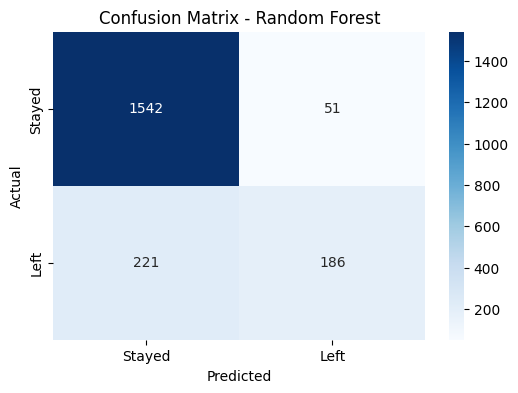

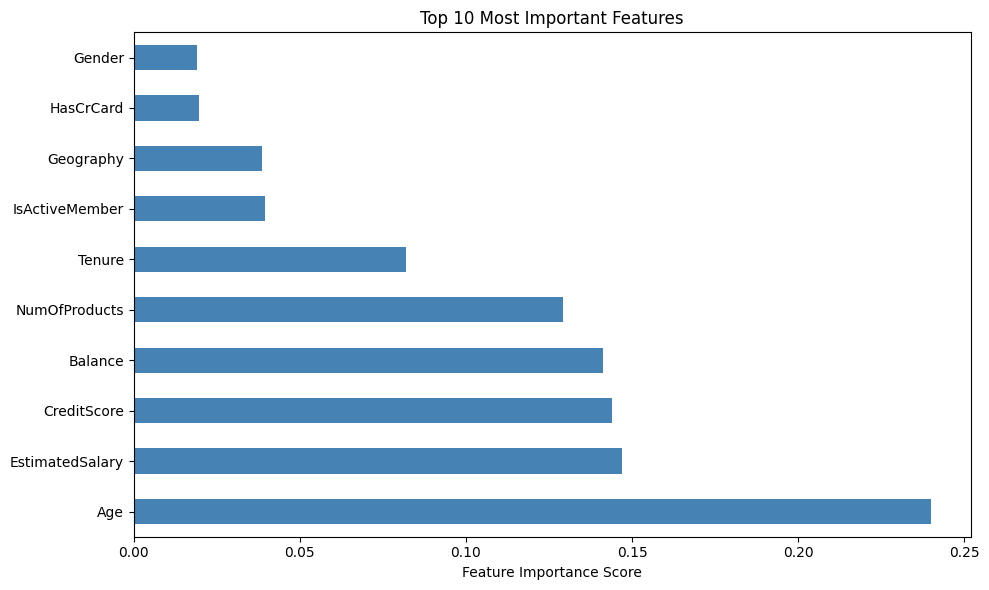


--- Project Summary ---
Dataset: 10,000 bank customer records
Models compared: Logistic Regression, Random Forest, XGBoost
Best Model: Random Forest
Best Accuracy: 86.4%


In [8]:
# Detailed results for best model (Random Forest)
print("Best Model: Random Forest")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Left']))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
plt.figure(figsize=(10,6))
feature_importance = pd.Series(rf_model.feature_importances_,
                                index=df.drop('Exited', axis=1).columns)
feature_importance.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Important Features')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\n--- Project Summary ---")
print("Dataset: 10,000 bank customer records")
print("Models compared: Logistic Regression, Random Forest, XGBoost")
print("Best Model: Random Forest")
print("Best Accuracy: 86.4%")